# Numerical Differentiation

Consider a function $f(x)$ for which we want to know the derivative $f^\prime(x)$. 

+ When $f(x)$ is a continuous function that we can define at any $x$, then we can use the analytic value of $f^\prime(x)$ in order to understand the errors of our numerical schemes (as we did [last week](./3a_accuracy.ipynb)). 
+ In practice, we generally only have information about $f(x_i)$ sampled at a discrete number of points. In this case, typically, our resolution in $x$ -- the number of points at which we have sampled $f$ in our domain determines our accuracy in computing $f\prime$.


## Finite Differences: Derivatives at Discrete Points

The definition of a derviative from calculus describes taking the slope between two points infinitessimally spaced $h$ apart. 
$$ f^\prime(x) = \lim_{h \to 0} \frac{ f(x+h) - f(h)}{h} $$

If we **discretize**, i.e. break up the domain into chunks, $h$ is our spacing between points $x_i$, which introduces some approximation error on the derivative. 

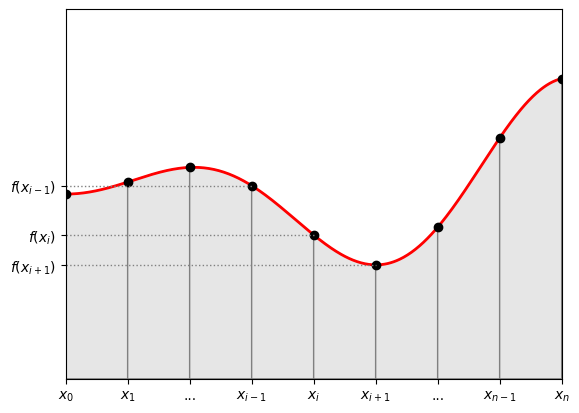

The Taylor expansion of $f$ yields that the discretized form of the derivative (first term) is off by a truncation error (second term+) of leading order $h$:
$$f^\prime(x) = \frac{f(x+h) - f(x)}{h} - \frac{h}{2} f^{\prime\prime}(x) + \ldots$$

As we found out last week, we have to consider both truncation and roundoff error in the total error.

```{note} Total Error
The sum of the roundoff error and the truncation error:
\varepsilon = \frac{2C\lvert f(x)\rvert}{h} + \frac{1}{2} h f''(x)

where $C = 2\times10^{-16}$ is the machine precision. 
```

For any given scheme, you can come up with the optimal size for $h$ by minimizing the function for the total error and solving for $h$. 

For the first-order scheme above:
$$h = \sqrt{4C\,\left| \frac{f(x)}{f''(x)} \right|}$$

Recall from last week:

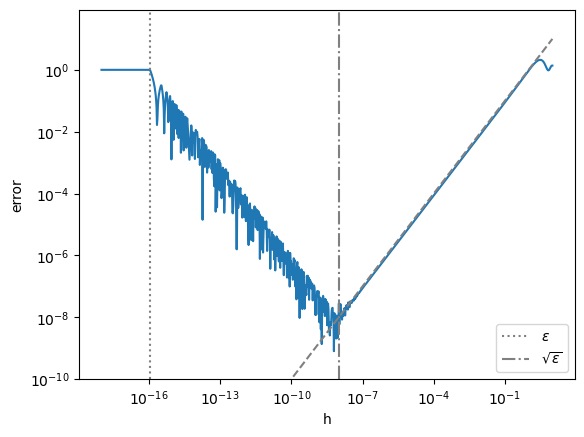

### Forward/Backward Differences
So far, the first order scheme we've been using is one that computes the derivative at $x_i$ using the slope between $x_{i+1}$ and $x_i$. This is called **forward-differencing**:  
$$f^\prime(x) = \frac{f(x+h) - f(x)}{h} = \frac{f_{i+1} - f_{i}}{\Delta x}$$

Alternatively, just like we could use left sums or right sums for integrals, we could use a stencil that computes the derivative at $x_i$ using the previous value at $x_{i-1}$, which is known as **backward-differencing**:

$$f^\prime(x) = \frac{f(x) - f(x-h)}{h} = \frac{f_{i} - f_{i-1}}{\Delta x}$$

These are both first-order methods, and either may be appropriate depending on context (behavior of $f$).

### Central Differences
However, we can also for greater accuracy use a three-point stencil centered on the point we are at, like in Simpson's method for integrals. 

$$f^\prime(x) = \frac{f(x+h) - f(x-h)}{2h} = \frac{f_{i+1} - f_{i-1}}{2\Delta x}$$

Note: that the effective step-size here is then $2h = 2\Delta x$. 

If you follow the derivation in the book, you'll see that central differences is a *second-order scheme*: with the total error scaling with $h^2$. 


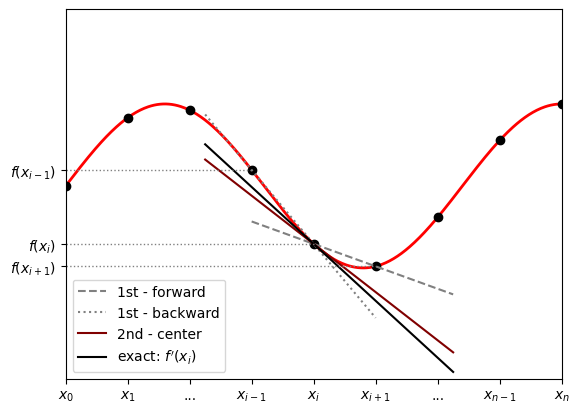

### Higher-Order Schemes
Using information from more points gives us greater accuracy, so by extension, you could imagine that higher-order schemes can be attained by using information from more points even further away. Just like for integration, we're essentially fitting higher order polynomials to our points to get more accurate representations of their behavior, 1st order is a derivative of a linear fit, 2nd order is a derivative of a quadratic fit, and so on...

For example, here is a 4th order central difference scheme:

$$f'(x) \simeq \frac{-f(x+2h) + 8f(x+h) - 8f(x-h) + f(x-2h)}{12h} = \frac{-f_{i+2} + 8f_{i+1} - 8f_{i-1} + f_{i-2}}{12\Delta x}$$





<h2><span class="fa fa-flash"></span> In-Class Coding Exercise </h2>

```{embed} #icc_4-5
```

<>:48: SyntaxWarning: invalid escape sequence '\p'
<>:48: SyntaxWarning: invalid escape sequence '\p'
/var/folders/hf/42bt2c2j3gs468tb5xz15j800000gp/T/ipykernel_65959/4070171890.py:48: SyntaxWarning: invalid escape sequence '\p'
  add_line(x_n[3],x_n[5],ax,label='exact: $f^\prime(x_i)$',order=0,ls='solid',mpt=x_n[4])


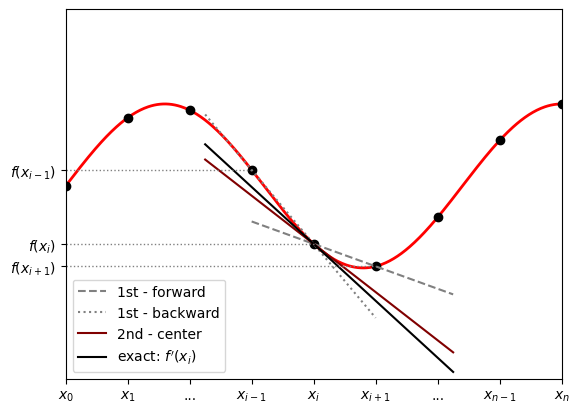

In [36]:
import numpy as np
import matplotlib.pyplot as plt 
from matplotlib.patches import Polygon

f,ax = plt.subplots()

x_a = np.linspace(0,2.5,500)
x_n = np.linspace(0,2.5,9)

def func(x):
    #return x ** 3 + (x - 0.5)**2 - x**4 + 0.5*x + 0.1*np.sin(x*10)
    return  1 + 0.25* np.sin(x*np.pi)

def fprime(x):
    return 0.25*np.pi*np.cos(x*np.pi)

def add_line(a,b,ax,order = 1,label='1st order',ls='dashed',mpt=0):
    if order == 1:
        m = (func(b) - func(a))/(b-a)
        c = func(a) - m * a
        ix = np.linspace(a*0.75, b*1.25,10)
        iy = m*ix + c
        ax.plot(ix,iy,color='gray', ls=ls,label=label)
    elif order == 2:
        m = (func(b) - func(a))/(b-a)
        c = func(mpt) - m * mpt
        ix = np.linspace(a*0.75, b*1.25,10)
        iy = m*ix + c
        ax.plot(ix,iy,color='maroon', ls=ls,label=label)
    elif order == 0:
        m = fprime(mpt)
        c = func(mpt) - m * mpt
        ix = np.linspace(a*0.75, b*1.25,10)
        iy = m*ix + c
        ax.plot(ix,iy,color='black', ls=ls,label=label)

f_a = func(x_a)
f_n = func(x_n)
ax.set_ylim(0,2)
ax.set_xlim(0,1)

ax.plot(x_a,f_a,lw=2,color='r')
ax.plot(x_n,f_n,linestyle="",marker='o',color='k')

add_line(x_n[4],x_n[5],ax,label='1st - forward')
add_line(x_n[3],x_n[4],ax,label='1st - backward',ls='dotted')
add_line(x_n[3],x_n[5],ax,label='2nd - center',order=2,ls='solid',mpt=x_n[4])
add_line(x_n[3],x_n[5],ax,label='exact: $f^\prime(x_i)$',order=0,ls='solid',mpt=x_n[4])
#for i in range(len(x_n)-1):
    #add_shape(x_n[i],x_n[i+1],ax)

def label(x):
    n = len(x)
    labels = []
    for i in range(n):
        if i < 3:
            if i!= 2:
                str_val = str(i)
                labels.append('$x_{}$'.format(str_val))
            else:
                labels.append("...")
        elif i == n-3:
                labels.append("...")
        elif i > n - 3:
            if i != n-1:
                str_val = "{n-" + str(n-i-1) + "}"
            else:
                str_val = "{n}"
            labels.append('$x_{}$'.format(str_val))
        else:
            i_mid = n//2
            i_val = i - i_mid 
            if i_val < 0:
                i_val = str(i_val)
            elif i_val > 0:
                i_val = "+" + str(i_val)
            else:
                i_val = ""
            str_val = "{i" + i_val + "}"
            labels.append('$x_{}$'.format(str_val))
    return labels

ax.set_xticks(x_n)
ax.set_xticklabels(label(x_n))
ax.set_yticks([func(x_n[3]),func(x_n[4]),func(x_n[5])])
ax.set_yticklabels(["$f(x_{i-1})$", "$f(x_{i})$", "$f(x_{i+1})$"])

ax.plot(x_n[:6],np.ones_like(x_n[:6])*func(x_n[5]),color='gray',lw=1,ls='dotted')
ax.plot(x_n[:5],np.ones_like(x_n[:5])*func(x_n[4]),color='gray',lw=1,ls='dotted')
ax.plot(x_n[:4],np.ones_like(x_n[:4])*func(x_n[3]),color='gray',lw=1,ls='dotted')
#ax.set_title("Rectangle Rule")
ax.set_ylim(func(x_n[4])*0.5,func(x_n[2])*1.25)
ax.legend()

## Construcing Other Types of Derivatives

### Second Derivative

Let's construct a difference approximation to the second derivative.

We can use the same Taylor expansions as before, but now including more terms:

$$f(x \pm h) = f(x) \pm f^\prime(x) h + \frac{1}{2} f^{\prime\prime}(x) h^2  \pm \frac{1}{6} f^{\prime\prime\prime}(x) h^3 + \mathcal{O}(h^4)$$
    
Now, you can eliminate the first derivative by combining these by using a three-point stencil:

$$f(x+h) + f(x-h) = 2 f(x) + f^{\prime\prime}(x) h^2 + \mathcal{O}(h^4)$$

(Notice that the third-derivative term also cancels)


```{embed} ex_4-3
```

```{embed} sol_4-3
```

### Partial Derivatives

For partial derivatives in multiple dimensions, you can apply the scheme to one variable. 

For example, in a central difference scheme:

$$\frac{\partial f}{\partial x} = \frac{f(x + h, y) - f(x - h, y)}{2h}$$
$$\frac{\partial f}{\partial y} = \frac{f(x, y + h) - f(x, y - h)}{2h}$$

And for a second-derivative then:
$$\frac{\partial^{2} f}{\partial x \partial y} = \frac{f(x+h, y+h) - f(x-h, y+h) - f(x+h, y-h) + f(x-h, y-h)}{4h^2}$$


## Adaptive Schemes

Based on the Taylor expansion:

$$f(x \pm h) = f(x) \pm f^\prime(x) h + \frac{1}{2} f^{\prime\prime}(x) h^2  \pm \frac{1}{6} f^{\prime\prime\prime}(x) h^3 + \mathcal{O}(h^4)$$

We know that in central differencing, the numerical derivative at one choice of h:
$$\Delta_1  = \frac{f(x + h) - f(x - h)}{2h} = f' + \frac{1}{6} h^2 f''' + \mathcal{O}(h^4)$$

has a truncation error of order $h^2$. 

Just like we did with integrals, we could account for our known error with a *Richardson extrapolation* by halving the value of $h$:

$$\Delta_2  = \frac{f(x + h/2) - f(x - h/2)}{h} = f' + \frac{1}{24} h^2 f''' + \mathcal{O}(h^4)$$

for a new estimate on $f'$:

$$f' = -\frac{\Delta_1 - 4 \Delta_2}{3} + \mathcal{O}(h^4)$$

which ends up being **fourth-order accurate**!
